## Add Bear Ridge to sea ice mask

Following e.g. 
- Naughten et al 2022 https://agupubs.onlinelibrary.wiley.com/doi/full/10.1029/2021GL094566
- Bett et al. 2020 https://agupubs.onlinelibrary.wiley.com/doi/10.1029/2020JC016305

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import netCDF4 as nc
import xarray as xr
import glob,os
import cmocean.cm as cmocean

from dask.distributed import Client
import cmocean as cm

In [2]:
client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 7
Total threads: 28,Total memory: 251.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:41993,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:44355,Total threads: 4
Dashboard: /proxy/35607/status,Memory: 35.88 GiB
Nanny: tcp://127.0.0.1:43021,


Load currently used files

In [3]:
kmt = xr.open_dataset('/g/data/x77/cy8964/mom6/input/input-8km/17.06.26/kmt.nc')
topog_seaice = xr.open_dataset('/g/data/x77/cy8964/mom6/input/input-8km/17.06.26/topog_seaice.nc')
topog = xr.open_dataset('/g/data/x77/cy8964/mom6/input/input-8km/22.06.26/topog.nc')
ice_shelf_thick = xr.open_dataset('/g/data/x77/cy8964/mom6/input/input-8km/22.06.26/ice_shelf_thick.nc')

### Naughten et al 2022

https://agupubs.onlinelibrary.wiley.com/doi/full/10.1029/2021GL094566

Data to see where mask is: https://ramadda.data.bas.ac.uk/repository/entry/show?entryid=synth:a4ea4d64-169a-4981-a64d-c2604b52522e:L2xhdGxvbi9FUkE1L01JVGdjbV9BbXVuZHNlblNlYV8xOTg4X3NlYV9pY2VfYXJlYV9mcmFjdGlvbl9FUkE1Lm5j 

saved at: `/g/data/x77/cy8964/mom6-panAn-iceshelf-tools/generate-draft/MITgcm_AmundsenSea_1988_sea_ice_area_fraction_ERA5.nc`

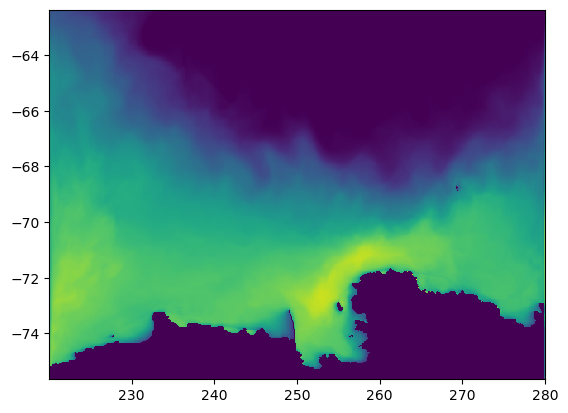

In [4]:
Naughten2022_seaice = xr.open_dataset('/g/data/x77/cy8964/mom6-panAn-iceshelf-tools/generate-draft/MITgcm_AmundsenSea_1988_sea_ice_area_fraction_ERA5.nc')

xx,yy = np.meshgrid(Naughten2022_seaice.XC,Naughten2022_seaice.YC, )

plt.pcolormesh(xx,yy,
               Naughten2022_seaice.sea_ice_area_fraction.mean('time'),
              shading = 'nearest')

(-75.6, -70.0)

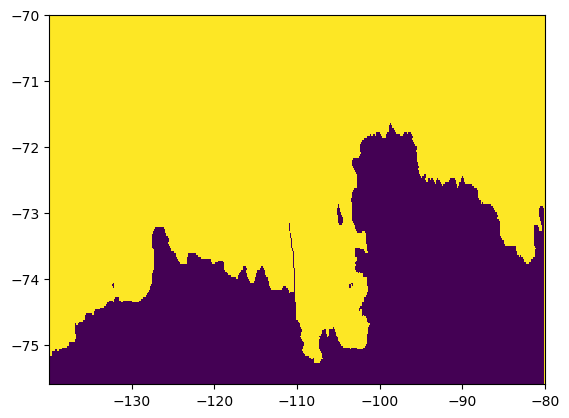

In [5]:
Naughten2022_mask = (Naughten2022_seaice.sea_ice_area_fraction.mean('time').where(Naughten2022_seaice.sea_ice_area_fraction.mean('time')>0)*0+1).fillna(0)
plt.pcolormesh(xx-360,yy,
               Naughten2022_mask,
              shading = 'nearest')
plt.ylim(-75.6,-70)

### Grounded Iceberg Dataset from Kaihong Jiao et al. https://essd.copernicus.org/articles/18/6017/2026/

Data: https://metadata.imas.utas.edu.au/geonetwork/srv/eng/catalog.search#/metadata/fed75718-1513-49cf-8253-a19347e7aeec

Saved here: `/g/data/x77/cy8964/satellite-meltrate/Jiao_grounded_iceberg/Antarctic_Grounded_Iceberg_Dataset_Sentinel1_v1.2.gpkg`

In [6]:
import geopandas as gpd

# Load the file into a GeoDataFrame
gdf = gpd.read_file("/g/data/x77/cy8964/satellite-meltrate/Jiao_grounded_iceberg/Antarctic_Grounded_Iceberg_Dataset_Sentinel1_v1.2.gpkg",
                   )

In [7]:
iceberg_lats = gdf.Latitude.values
iceberg_lons = gdf.Longitude.values
iceberg_size = gdf.Area_Mean_km2

Am_lat_max = -70
Am_lat_min = -76
Am_lon_max = -80
Am_lon_min = -140

Am_icebergs_lat = iceberg_lats[(iceberg_lats<Am_lat_max) & (iceberg_lats>Am_lat_min) & (iceberg_lons<Am_lon_max) & (iceberg_lons>Am_lon_min)]
Am_icebergs_lon = iceberg_lons[(iceberg_lats<Am_lat_max) & (iceberg_lats>Am_lat_min) & (iceberg_lons<Am_lon_max) & (iceberg_lons>Am_lon_min)]
Am_icebergs_size = iceberg_size[(iceberg_lats<Am_lat_max) & (iceberg_lats>Am_lat_min) & (iceberg_lons<Am_lon_max) & (iceberg_lons>Am_lon_min)]


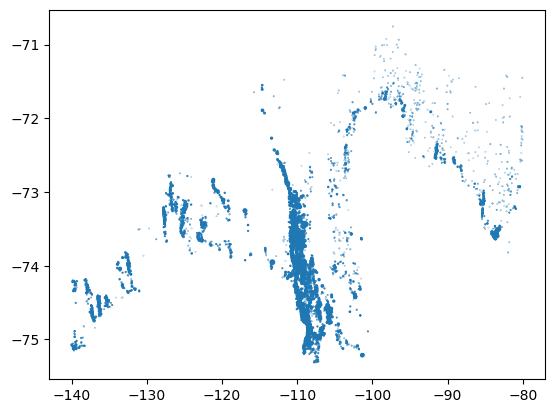

In [8]:
plt.scatter(Am_icebergs_lon,Am_icebergs_lat, s = Am_icebergs_size)

# Plot it all together

/jobfs/178324788.gadi-pbs/ipykernel_1980287/2555263196.py:5: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(xx-360,yy,


/g/data/xp65/public/apps/med_conda/envs/analysis3-26.09/lib/python3.12/site-packages/IPython/core/events.py:100: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)


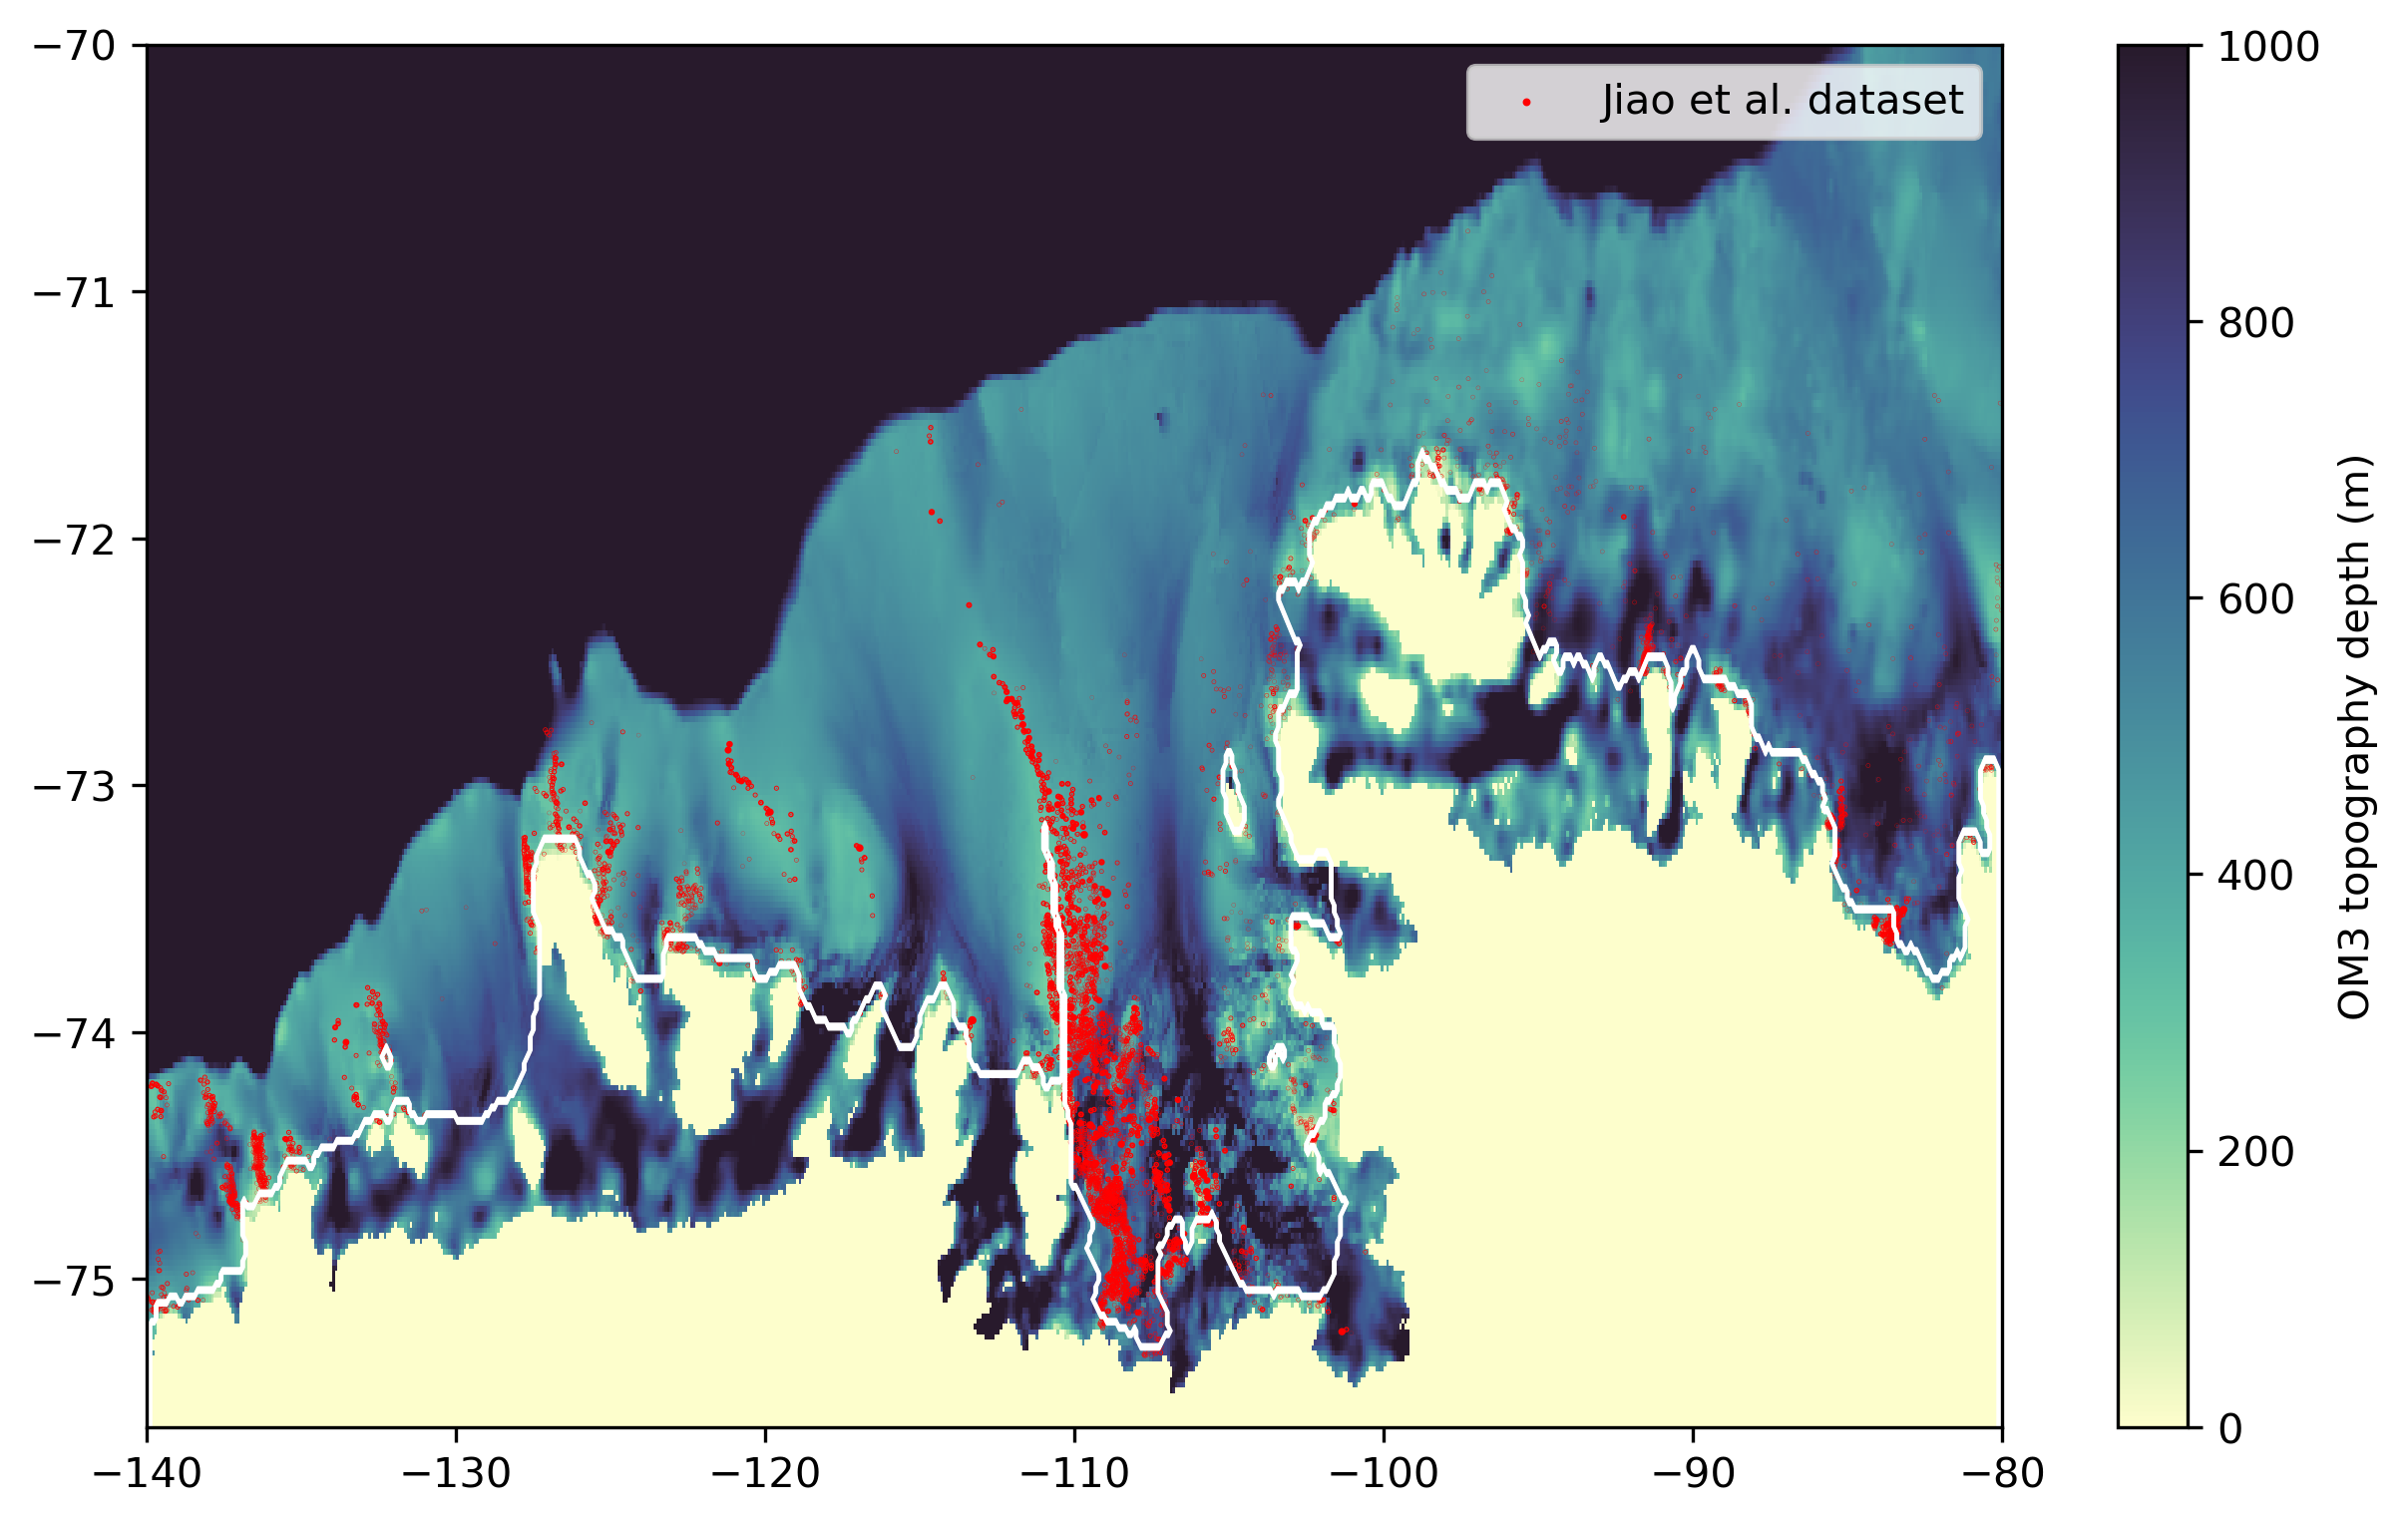

In [9]:
fig, axes = plt.subplots(figsize = (10,6), dpi = 300)

plt.pcolormesh(topog.lon,topog.lat,topog.depth, vmax = 1000, cmap = cm.cm.deep)
plt.colorbar(label = 'OM3 topography depth (m)')
plt.contour(xx-360,yy,
               Naughten2022_mask,colors = 'w', label = 'Naughten et al. 2022', linewidths = 0.5)
plt.scatter(Am_icebergs_lon,Am_icebergs_lat, s = Am_icebergs_size/10, c = 'r', label = 'Jiao et al. dataset')
plt.ylim(-75.6,-70)
plt.xlim(-140,-80)
plt.legend()

Lots of icebergs!

### Zoom into Bear Ridge region

And find coordinates of kmt (sea ice mask) which approximately line up with Naughten et al. 2022 Bear Ridge edits/300m isobath contour

/jobfs/178324788.gadi-pbs/ipykernel_1980287/1940528524.py:18: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


/g/data/xp65/public/apps/med_conda/envs/analysis3-26.09/lib/python3.12/site-packages/IPython/core/events.py:100: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)


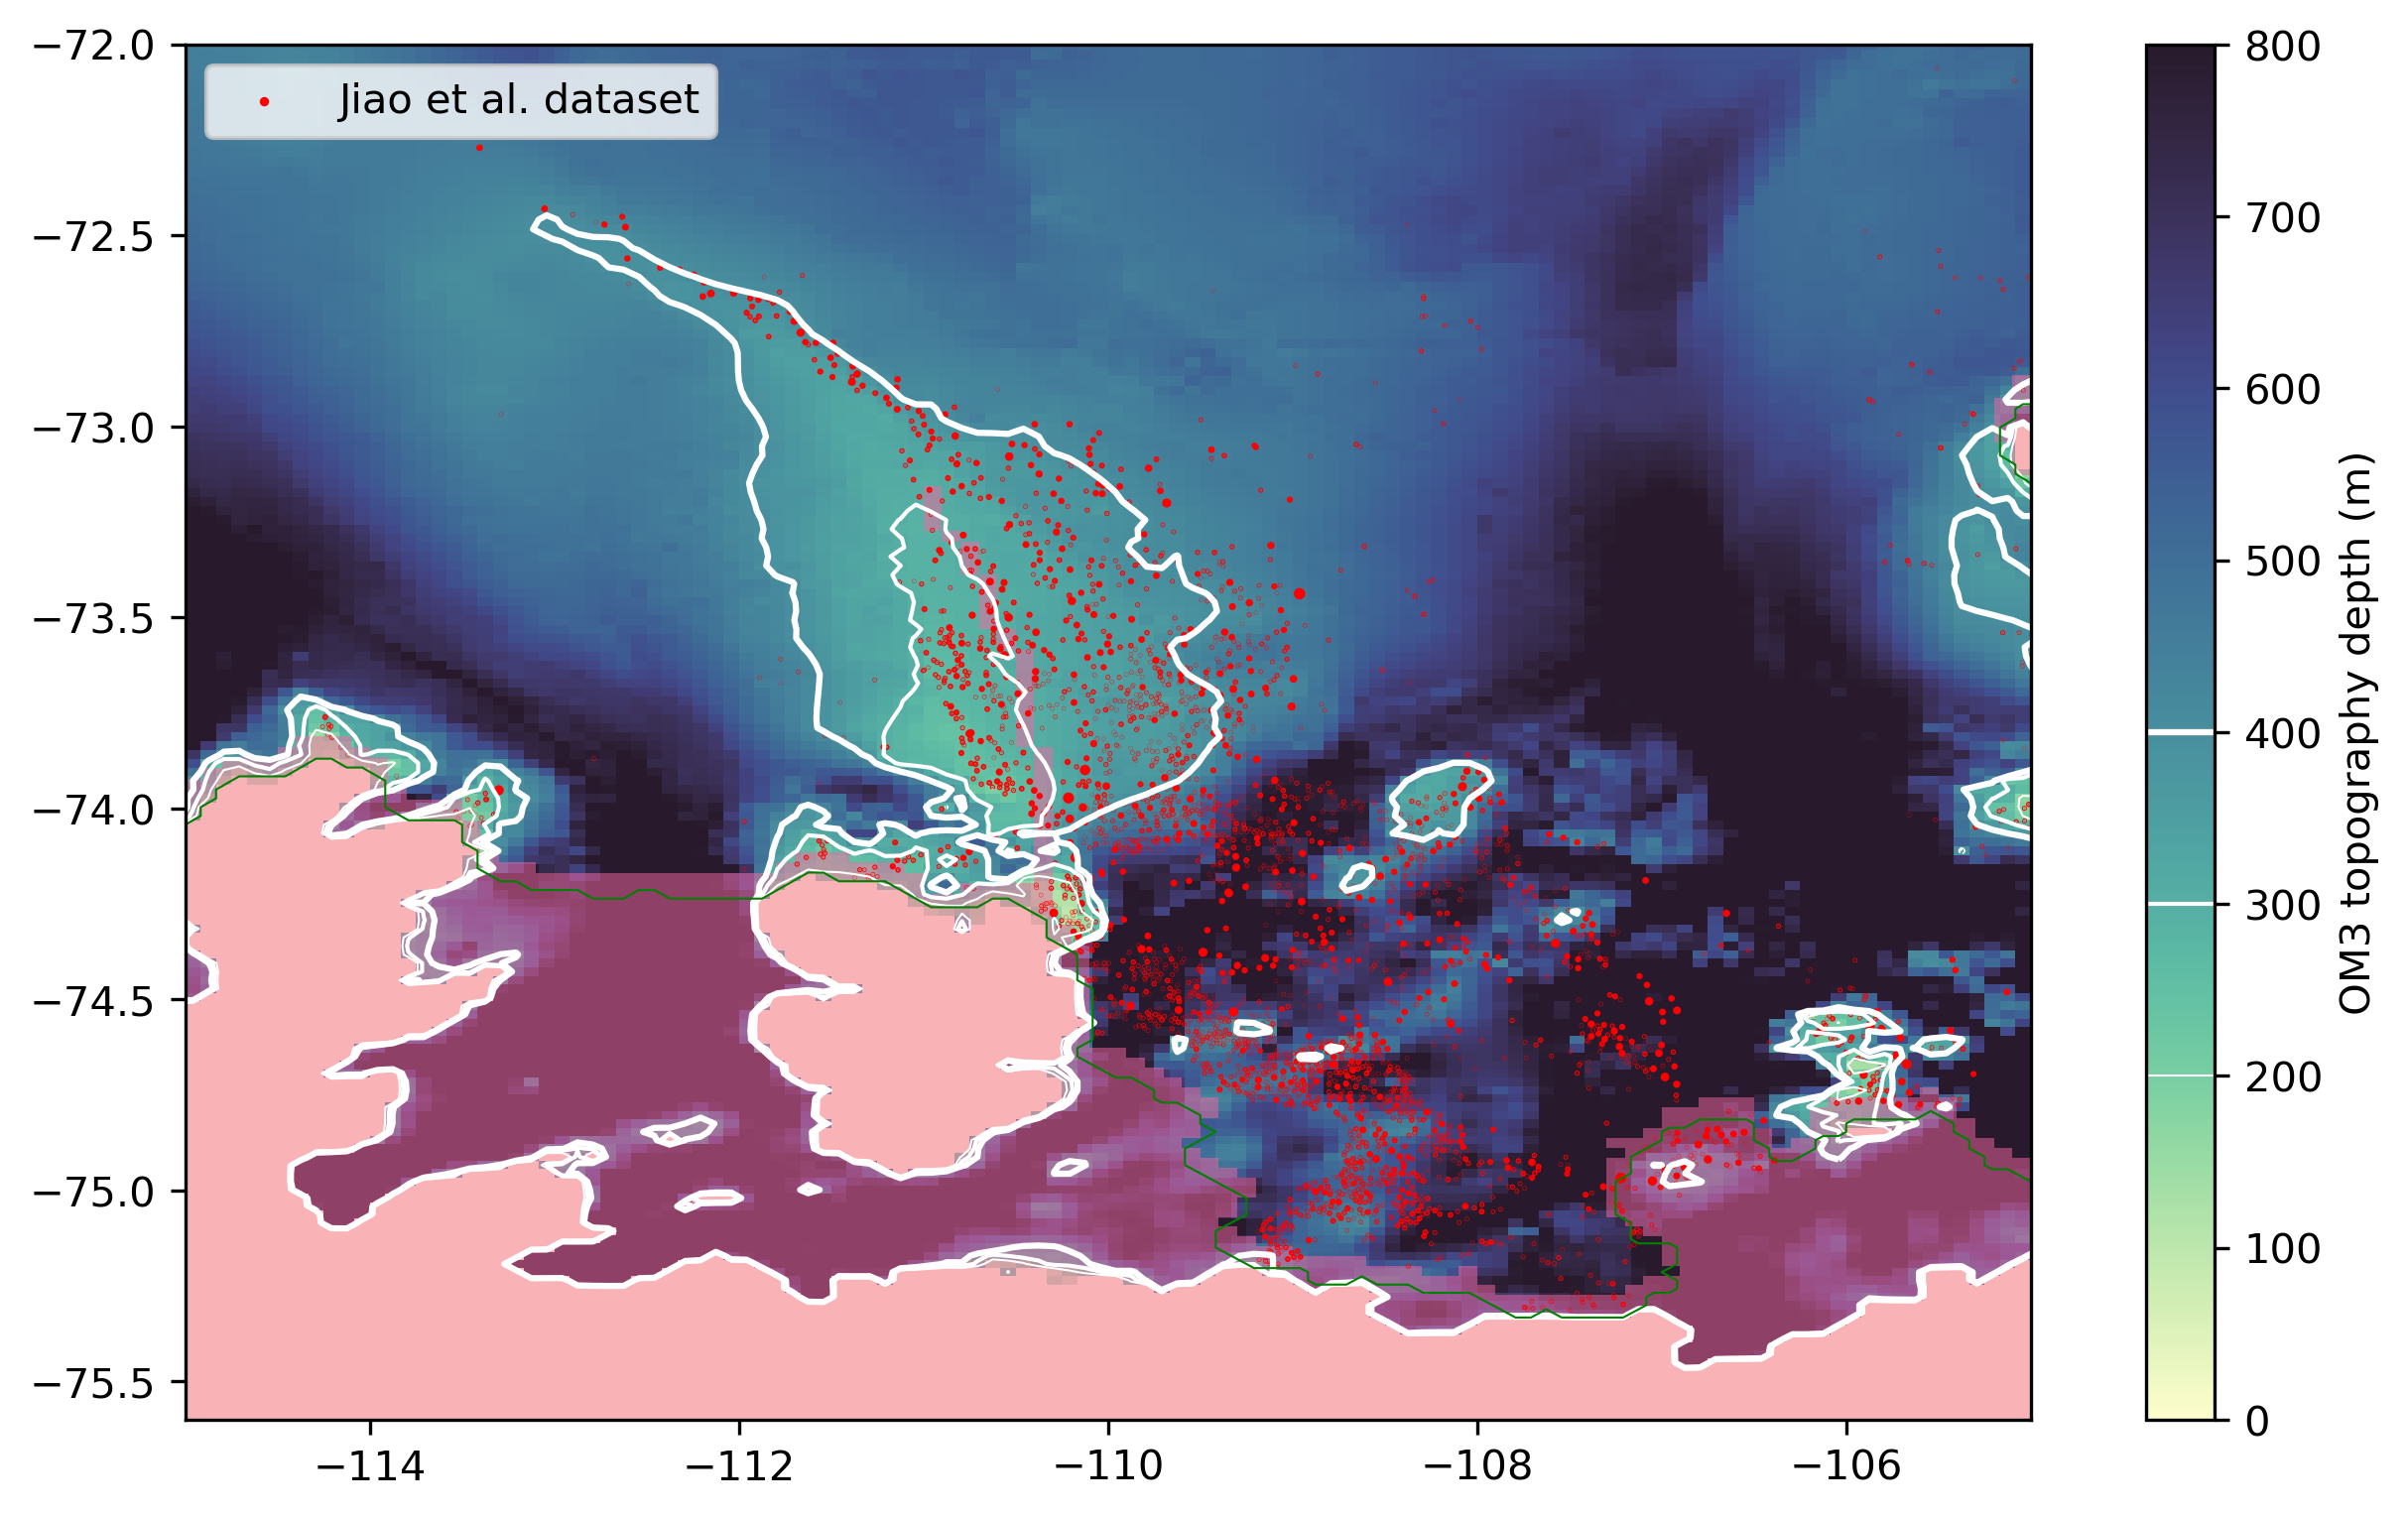

In [10]:
fig, axes = plt.subplots(figsize = (10,6), dpi = 300)

plt.pcolormesh(topog.lon,topog.lat,topog.depth, vmax = 800, cmap = cm.cm.deep)
cbar = plt.colorbar(label = 'OM3 topography depth (m)')

ls = plt.contour(topog.lon,topog.lat,topog.depth, levels = [200,300,400], colors = 'w', linewidths = [0.5,1,1.5])
cbar.add_lines(ls)

#h1,l1 = ls.legend_elements()

naughten = plt.pcolormesh(xx-360,yy,
               Naughten2022_mask.where(Naughten2022_mask==0)*0+1, label = 'Naughten et al. 2022', alpha = 0.5, cmap = 'RdPu', vmax = 2, vmin= 0)
#h2,l2 = naughten.legend_elements()
plt.contour(topog.lon,topog.lat,kmt.kmt, levels = [0.5], colors = 'g', linewidths = 0.5)
plt.scatter(Am_icebergs_lon,Am_icebergs_lat, s = Am_icebergs_size/5, c = 'r', label = 'Jiao et al. dataset')
plt.ylim(-75.6,-72)
plt.xlim(-115,-105)
plt.legend()

Find location of points

/jobfs/178324788.gadi-pbs/ipykernel_1980287/528800937.py:47: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


/g/data/xp65/public/apps/med_conda/envs/analysis3-26.09/lib/python3.12/site-packages/IPython/core/events.py:100: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)


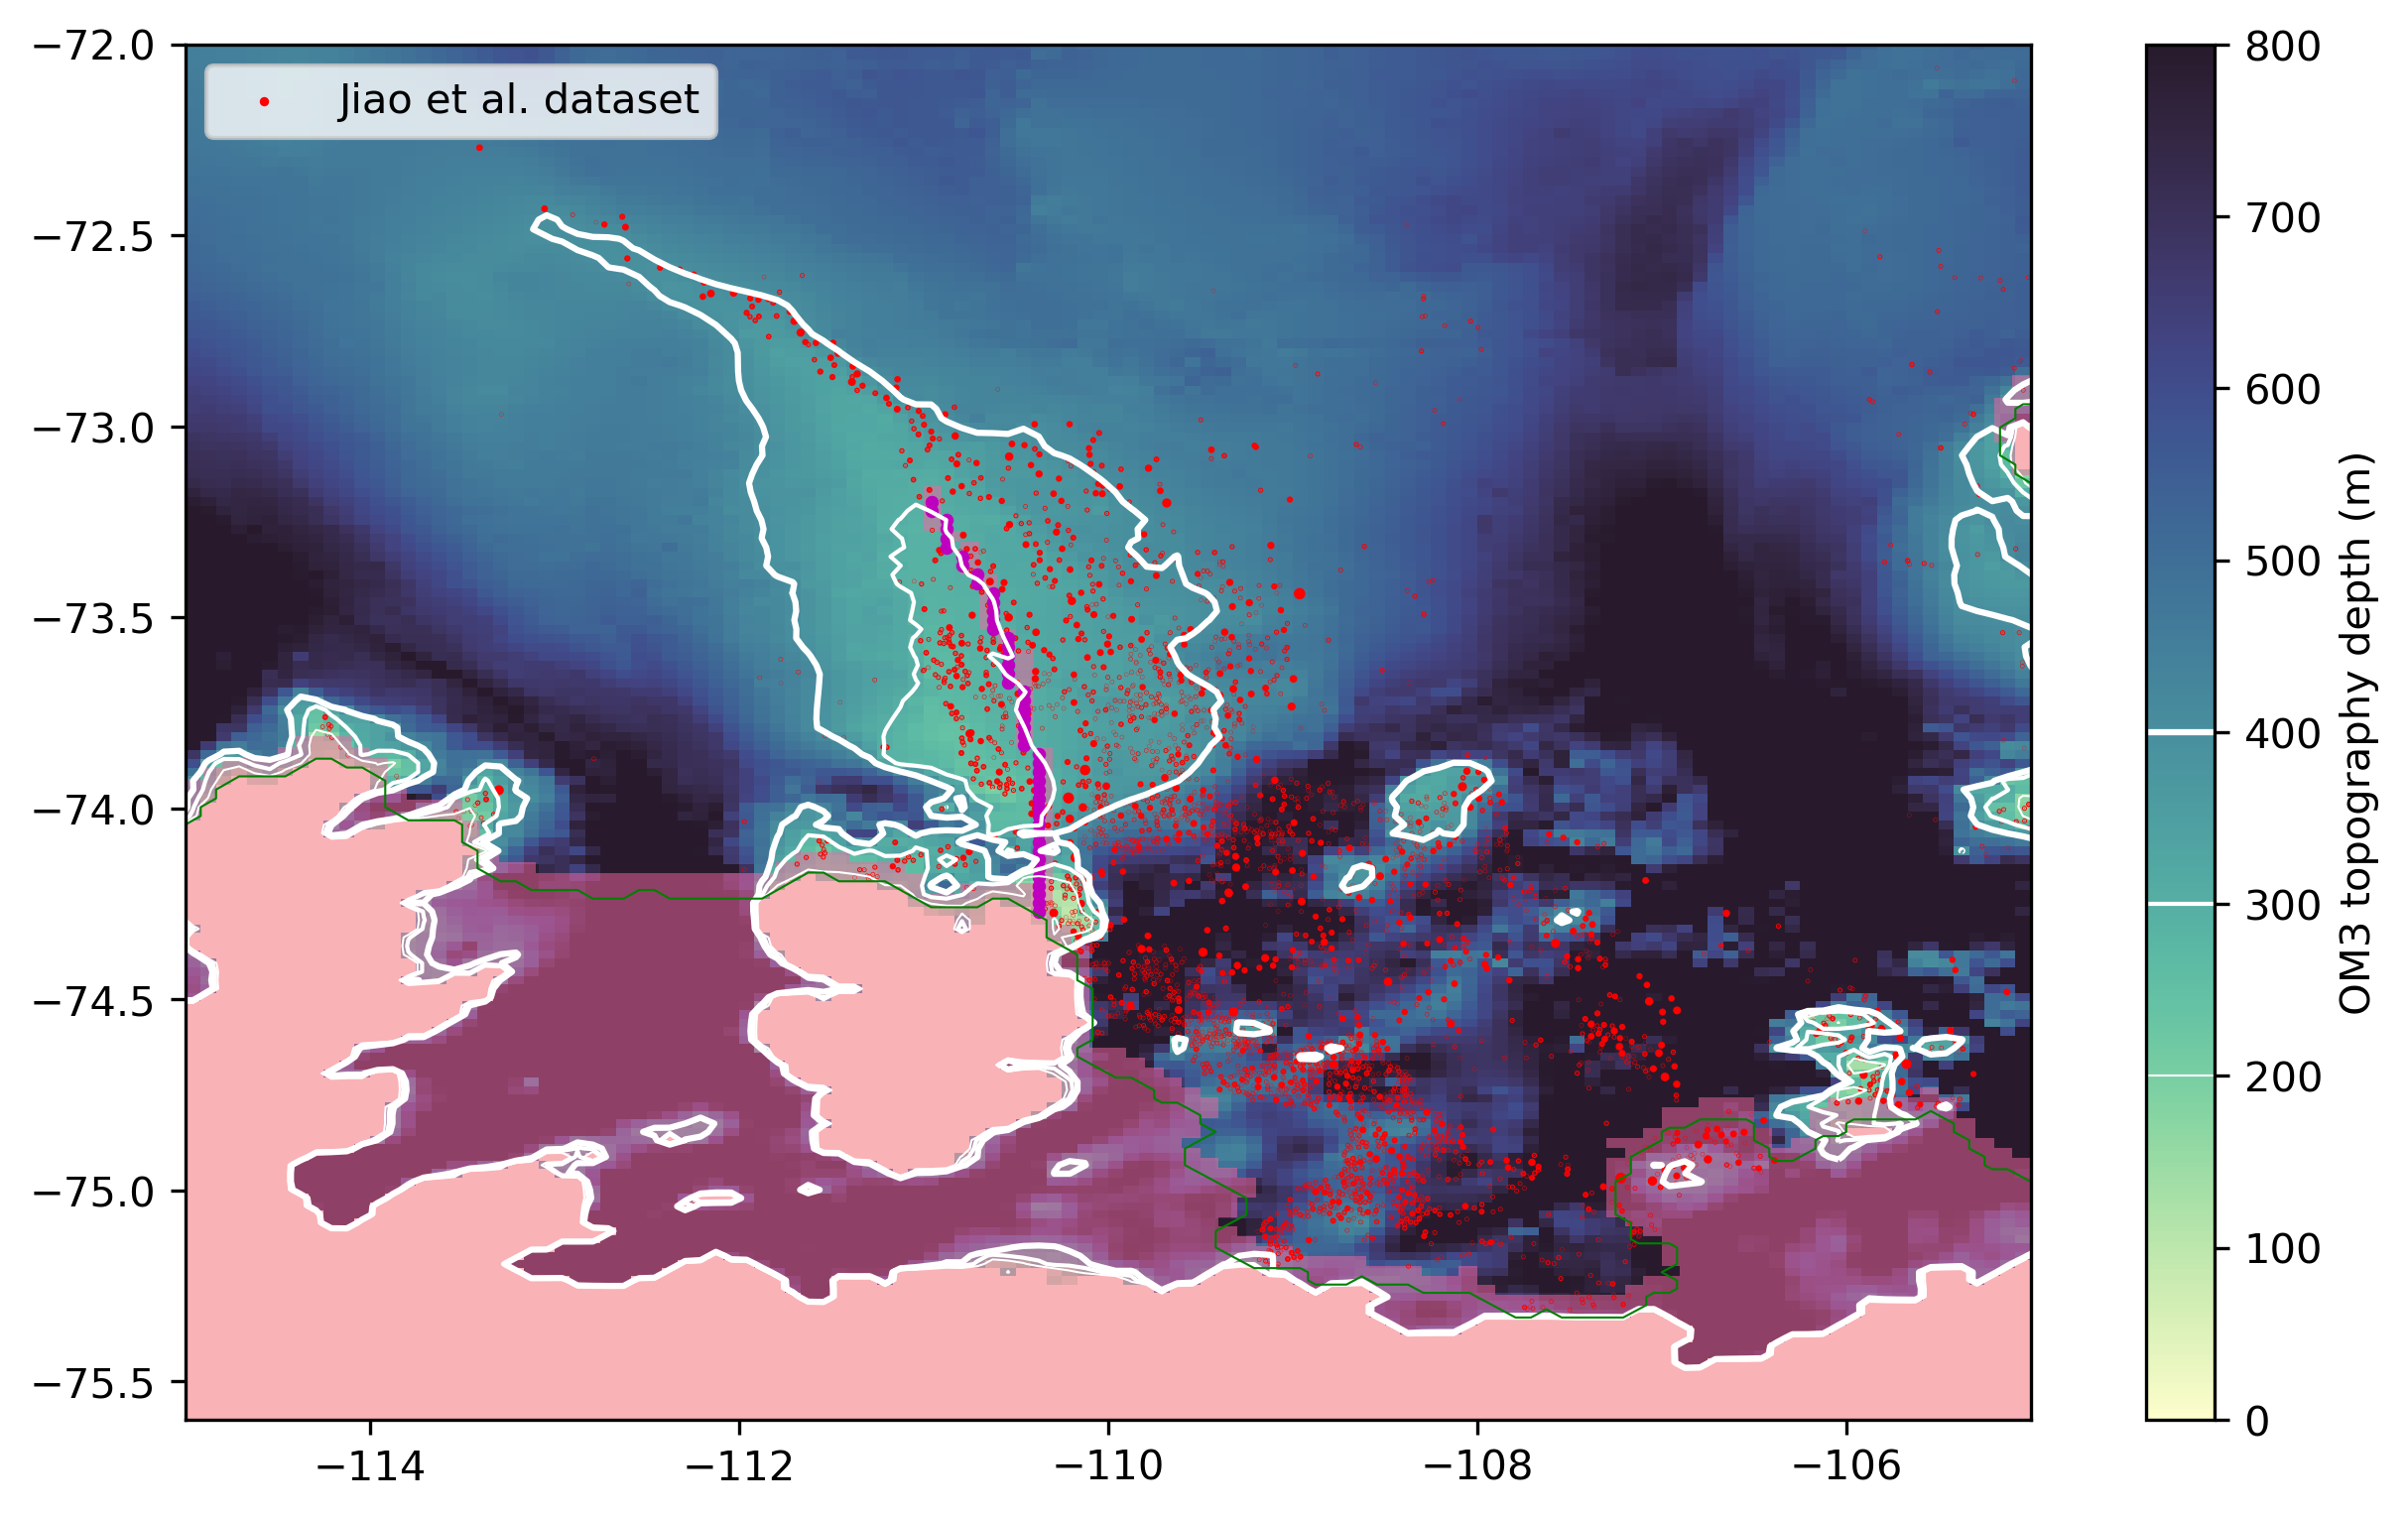

In [11]:
fig, axes = plt.subplots(figsize = (10,6), dpi = 300)

plt.pcolormesh(topog.lon,topog.lat,topog.depth, vmax = 800, cmap = cm.cm.deep)
cbar = plt.colorbar(label = 'OM3 topography depth (m)')

ls = plt.contour(topog.lon,topog.lat,topog.depth, levels = [200,300,400], colors = 'w', linewidths = [0.5,1,1.5])
cbar.add_lines(ls)

#h1,l1 = ls.legend_elements()

naughten = plt.pcolormesh(xx-360,yy,
               Naughten2022_mask.where(Naughten2022_mask==0)*0+1, label = 'Naughten et al. 2022', alpha = 0.5, cmap = 'RdPu', vmax = 2, vmin= 0)
#h2,l2 = naughten.legend_elements()
plt.contour(topog.lon,topog.lat,kmt.kmt, levels = [0.5], colors = 'g', linewidths = 0.5)
plt.scatter(Am_icebergs_lon,Am_icebergs_lat, s = Am_icebergs_size/5, c = 'r', label = 'Jiao et al. dataset')
plt.ylim(-75.6,-72)
plt.xlim(-115,-105)


# plot the points to mask out
BearRidge_edited_kmt = kmt.copy(deep=True)

plt.scatter([BearRidge_edited_kmt.lon.values[566:585,2035]],
            [BearRidge_edited_kmt.lat.values[566:585,2035]],
            s = 5, color = 'm')
plt.scatter([BearRidge_edited_kmt.lon.values[585:592,2034]],
            [BearRidge_edited_kmt.lat.values[585:592,2034]],
            s = 5, color = 'm')
plt.scatter([BearRidge_edited_kmt.lon.values[592:598,2033]],
            [BearRidge_edited_kmt.lat.values[592:598,2033]],
            s = 5, color = 'm')
plt.scatter([BearRidge_edited_kmt.lon.values[598:603,2032]],
            [BearRidge_edited_kmt.lat.values[598:603,2032]],
            s = 5, color = 'm')
plt.scatter([BearRidge_edited_kmt.lon.values[603:605,2031]],
            [BearRidge_edited_kmt.lat.values[603:605,2031]],
            s = 5, color = 'm')
plt.scatter([BearRidge_edited_kmt.lon.values[605:607,2030]],
            [BearRidge_edited_kmt.lat.values[605:607,2030]],
            s = 5, color = 'm')
plt.scatter([BearRidge_edited_kmt.lon.values[607:611,2029]],
            [BearRidge_edited_kmt.lat.values[607:611,2029]],
            s = 5, color = 'm')
plt.scatter([BearRidge_edited_kmt.lon.values[611:613,2028]],
            [BearRidge_edited_kmt.lat.values[611:613,2028]],
            s = 5, color = 'm')
plt.legend()

### Edit kmt file

(-115.0, -105.0)

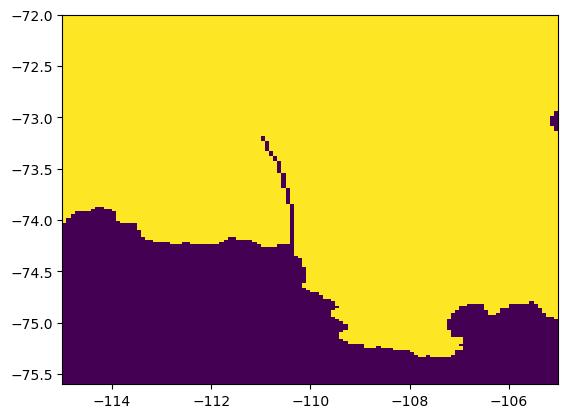

In [12]:
BearRidge_edited_kmt = kmt.copy(deep=True)

BearRidge_edited_kmt['kmt'][567,2034]=0 #for bgrid connectivity
BearRidge_edited_kmt['kmt'][566:585,2035]=0
BearRidge_edited_kmt['kmt'][585:592,2034]=0
BearRidge_edited_kmt['kmt'][592:598,2033]=0
BearRidge_edited_kmt['kmt'][598:603,2032]=0
BearRidge_edited_kmt['kmt'][603:605,2031]=0
BearRidge_edited_kmt['kmt'][605:607,2030]=0
BearRidge_edited_kmt['kmt'][607:611,2029]=0
BearRidge_edited_kmt['kmt'][611:613,2028]=0

plt.pcolormesh(topog.lon,topog.lat,BearRidge_edited_kmt.kmt)
plt.ylim(-75.6,-72)
plt.xlim(-115,-105)


Double check which points have been changed (green ones)

(-115.0, -105.0)

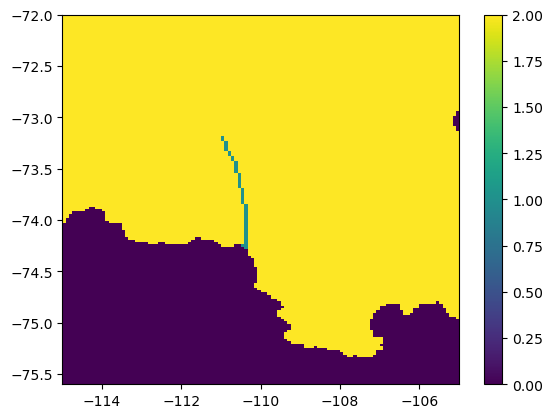

In [13]:
plt.pcolormesh(topog.lon,topog.lat,BearRidge_edited_kmt.kmt + kmt.kmt)
plt.colorbar()
plt.ylim(-75.6,-72)
plt.xlim(-115,-105)


And plot with all the data

(-115.0, -105.0)

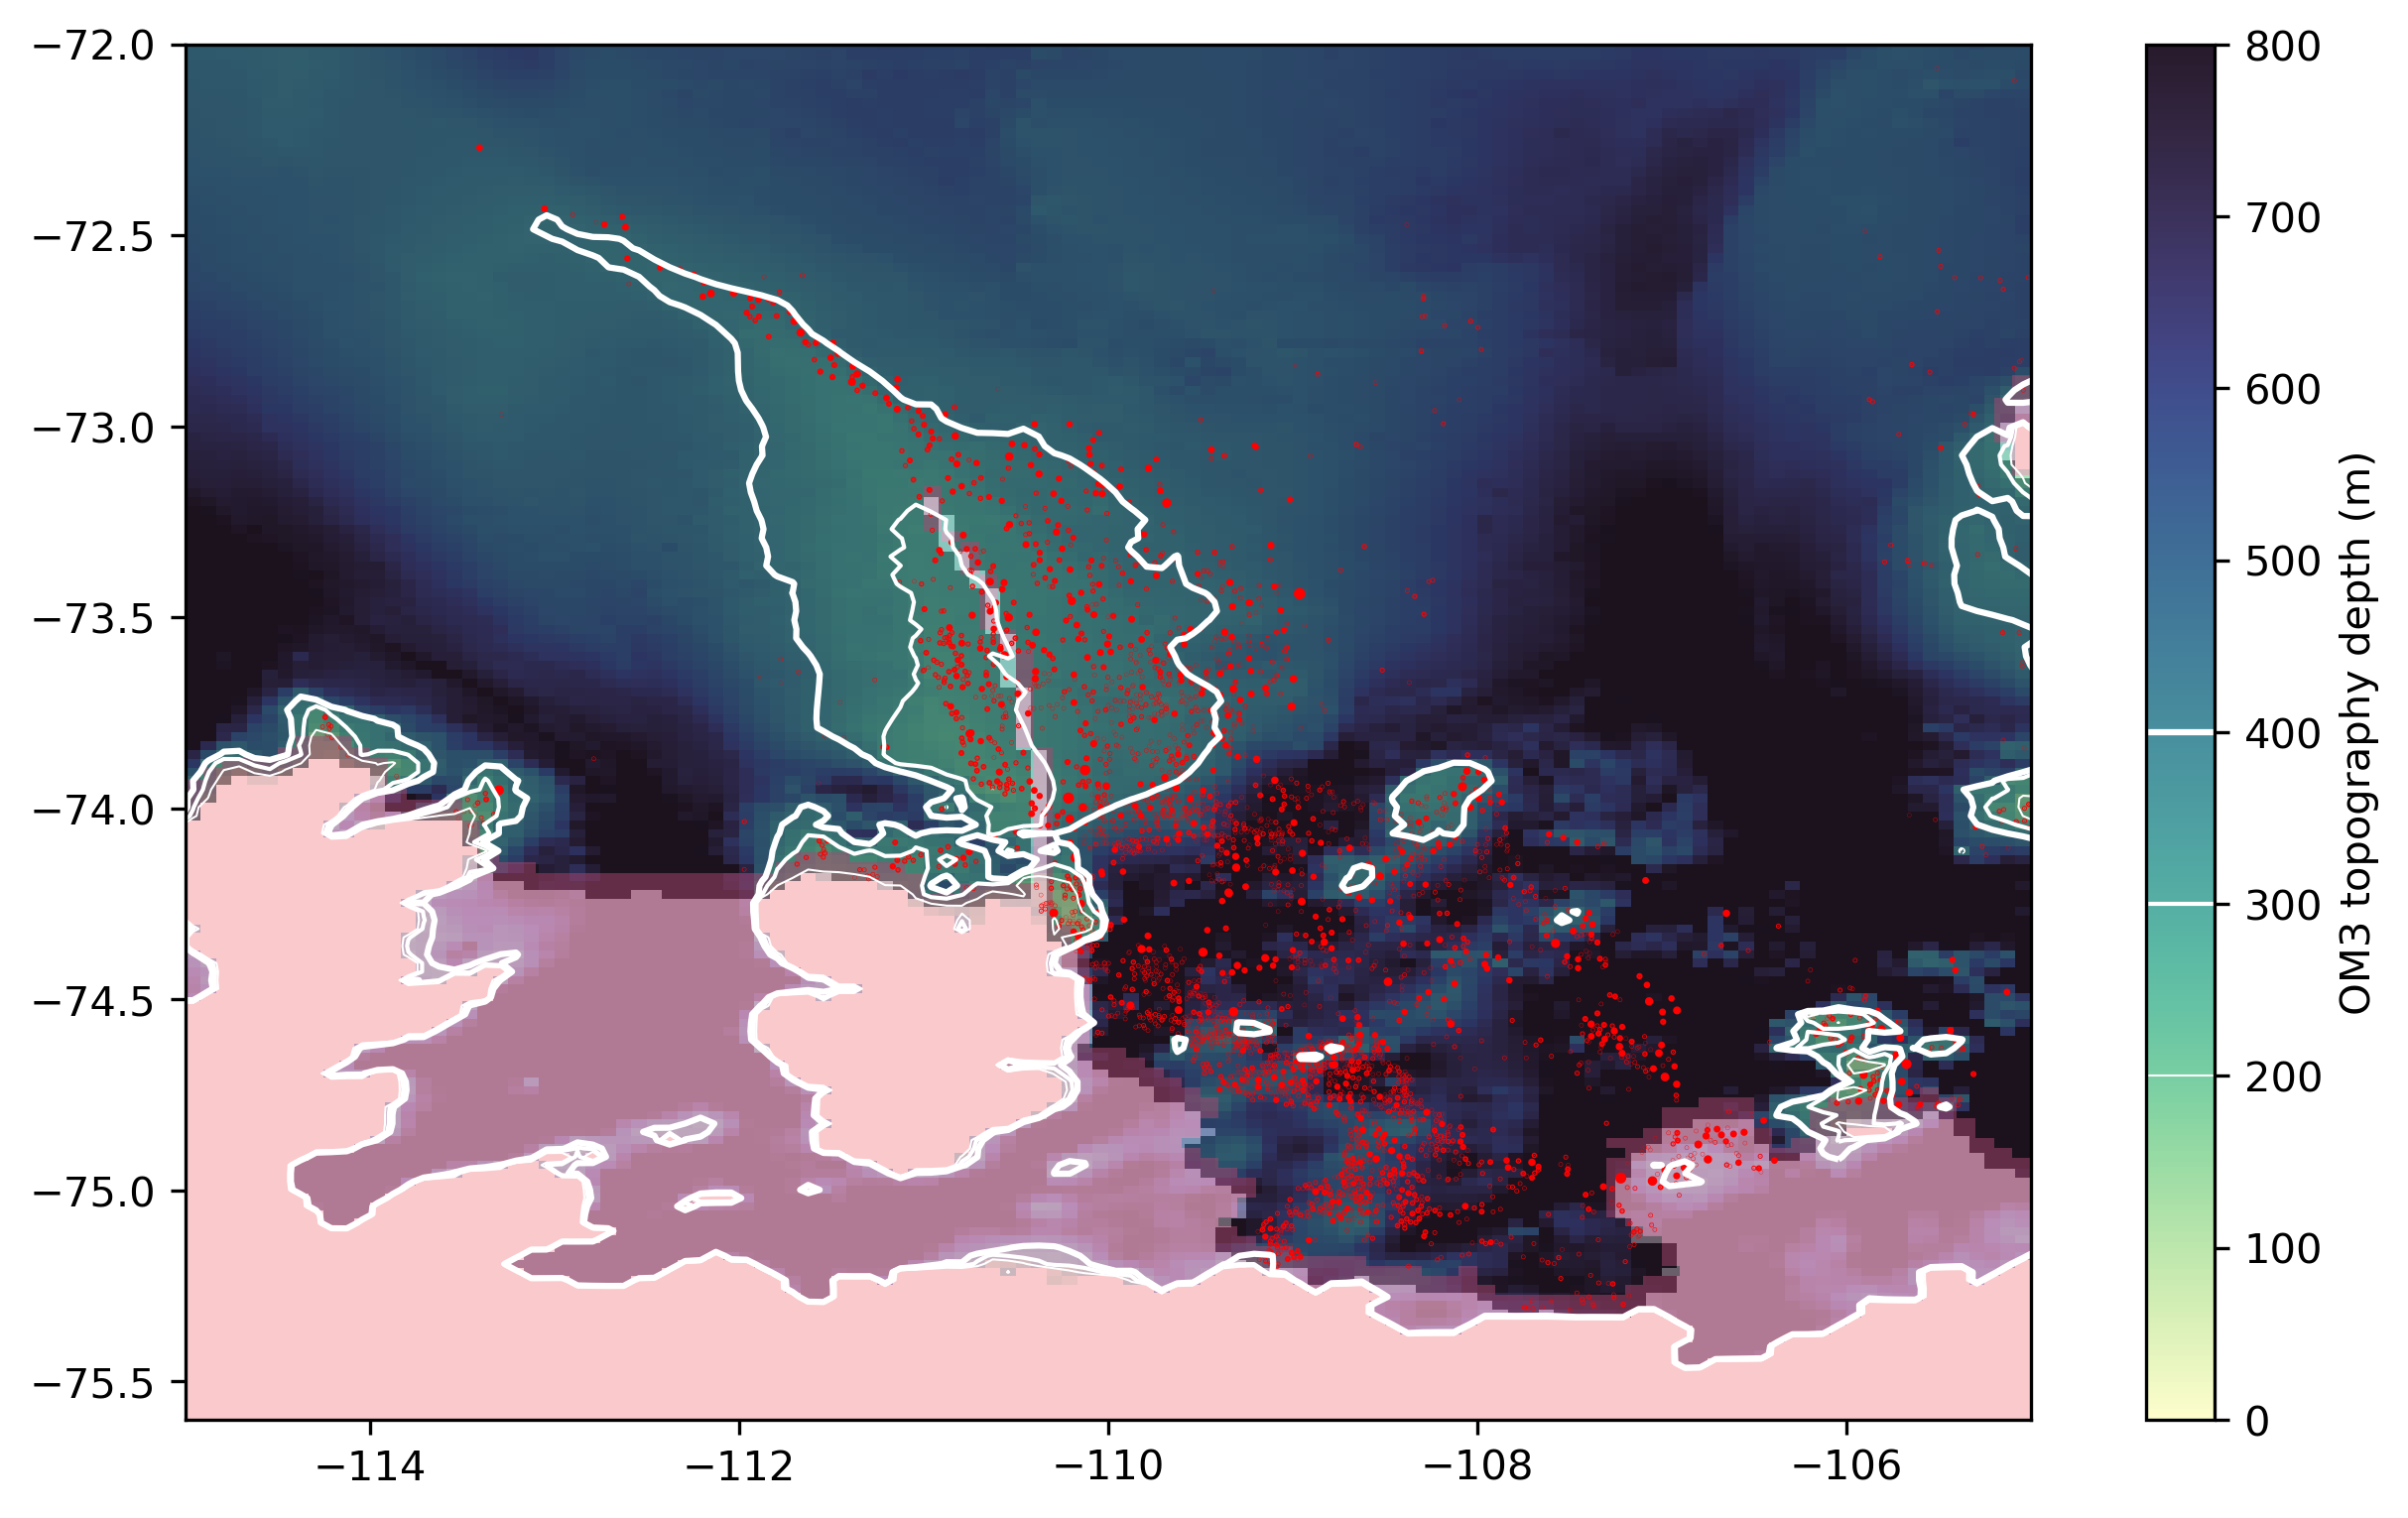

In [16]:
fig, axes = plt.subplots(figsize = (10,6), dpi = 300)

plt.pcolormesh(topog.lon,topog.lat,topog.depth, vmax = 800, cmap = cm.cm.deep)
cbar = plt.colorbar(label = 'OM3 topography depth (m)')

ls = plt.contour(topog.lon,topog.lat,topog.depth, levels = [200,300,400], colors = 'w', linewidths = [0.5,1,1.5])
cbar.add_lines(ls)

#h1,l1 = ls.legend_elements()

naughten = plt.pcolormesh(xx-360,yy,
               Naughten2022_mask.where(Naughten2022_mask==0)*0+1, label = 'Naughten et al. 2022', alpha = 0.5, cmap = 'RdPu', vmax = 2, vmin= 0)
#h2,l2 = naughten.legend_elements()
plt.pcolormesh(topog.lon,topog.lat,BearRidge_edited_kmt.kmt, cmap = 'Greys', vmax = 1, vmin = 0,alpha = 0.3)
plt.scatter(Am_icebergs_lon,Am_icebergs_lat, s = Am_icebergs_size/5, c = 'r', label = 'Jiao et al. dataset')
plt.ylim(-75.6,-72)
plt.xlim(-115,-105)


## Now let's save this new kmt file

- We will also need to change the nuopc mask
- And the ice shelf mask to add these points (fast ice == ice shelf)

so that these sea-ice-free points don't talk to the atmos

Then we will also save topog.nc with this bear ridge edit too

In [15]:
BearRidge_edited_kmt.attrs['description'] = BearRidge_edited_kmt.attrs['description'] + ' Manually masked out Bear Ridge in Amundsen sea, see https://github.com/claireyung/mom6-panAn-iceshelf-tools/blob/main/generate-draft/bear-ridge-edits.ipynb'
BearRidge_edited_kmt

<xarray.Dataset> Size: 75MB
Dimensions:  (ny: 1442, nx: 4320)
Dimensions without coordinates: ny, nx
Data variables:
    lat      (ny, nx) float32 25MB ...
    lon      (ny, nx) float32 25MB ...
    kmt      (ny, nx) float32 25MB 0.0 0.0 0.0 0.0 0.0 ... 1.0 1.0 1.0 1.0 1.0
Attributes:
    description:  Charrassin 2025 depth regridded onto global 1/12th (8km) gr...

In [17]:
BearRidge_edited_kmt.to_netcdf('/g/data/x77/cy8964/mom6/input/input-8km/07.09.26-BearRidgeSI/kmt.nc')

(500.0, 700.0)

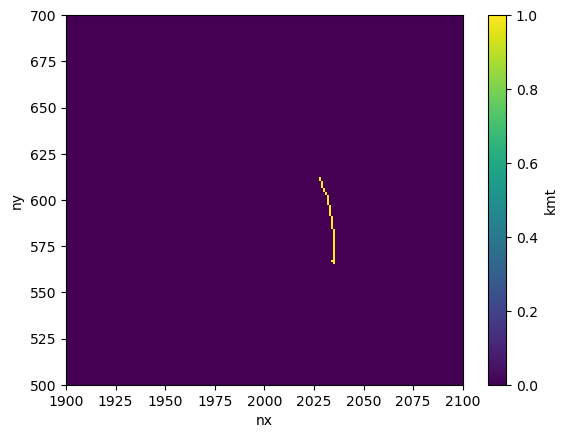

In [20]:
(-BearRidge_edited_kmt.kmt + kmt.kmt).plot()
plt.xlim(1900,2100)
plt.ylim(500,700)

In [23]:
ice_shelf_thick_BearRidge = ice_shelf_thick.copy(deep=True)
area_everywhere = xr.open_dataset('/g/data/x77/cy8964/mom6/input/input-8km-SIS2/area_everywhere.nc')
ice_shelf_thick_BearRidge['thick'] = ice_shelf_thick.thick + 0.01*(-BearRidge_edited_kmt.kmt + kmt.kmt).values #1cm thick landfast ice
ice_shelf_thick_BearRidge['h_mask'] = ice_shelf_thick.h_mask + (-BearRidge_edited_kmt.kmt + kmt.kmt).values
ice_shelf_thick_BearRidge['area'] = ice_shelf_thick.area + (-BearRidge_edited_kmt.kmt + kmt.kmt).values*area_everywhere.Ah.values

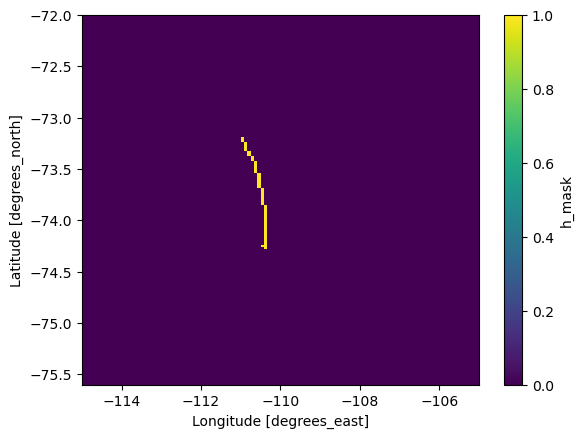

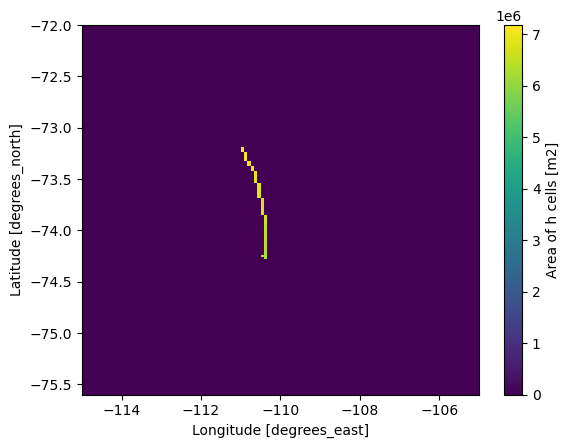

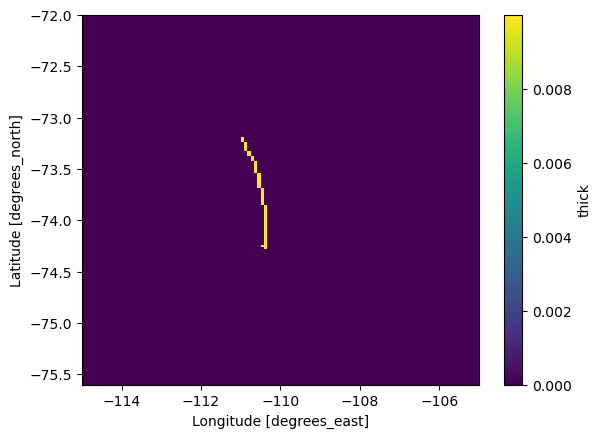

In [27]:
#check before and after
(ice_shelf_thick_BearRidge.h_mask - ice_shelf_thick.h_mask).plot()
plt.ylim(-75.6,-72)
plt.xlim(-115,-105)
plt.show()
(ice_shelf_thick_BearRidge.area - ice_shelf_thick.area).plot()
plt.ylim(-75.6,-72)
plt.xlim(-115,-105)
plt.show()
(ice_shelf_thick_BearRidge.thick - ice_shelf_thick.thick).plot()
plt.ylim(-75.6,-72)
plt.xlim(-115,-105)
plt.show()


In [28]:
ice_shelf_thick_BearRidge.attrs['description'] = ice_shelf_thick_BearRidge.attrs['description'] + ' Manually masked out Bear Ridge in Amundsen sea and added to ice shelf mask, see https://github.com/claireyung/mom6-panAn-iceshelf-tools/blob/main/generate-draft/bear-ridge-edits.ipynb'
ice_shelf_thick_BearRidge

<xarray.Dataset> Size: 174MB
Dimensions:  (ny: 1442, nx: 4320)
Coordinates:
  * ny       (ny) float64 12kB -86.49 -86.47 -86.45 ... -37.63 -37.56 -37.5
  * nx       (nx) float64 35kB -280.0 -279.9 -279.8 -279.7 ... 79.79 79.88 79.96
Data variables:
    thick    (ny, nx) float32 25MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    lat      (ny, nx) float32 25MB ...
    lon      (ny, nx) float32 25MB ...
    area     (ny, nx) float64 50MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    h_mask   (ny, nx) float64 50MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
Attributes:
    description:  Ice thickness (meters), float, 0 to 5000 meters. From Charr...

In [29]:
ice_shelf_thick_BearRidge.to_netcdf('/g/data/x77/cy8964/mom6/input/input-8km/07.09.26-BearRidgeSI/ice_shelf_thick.nc')

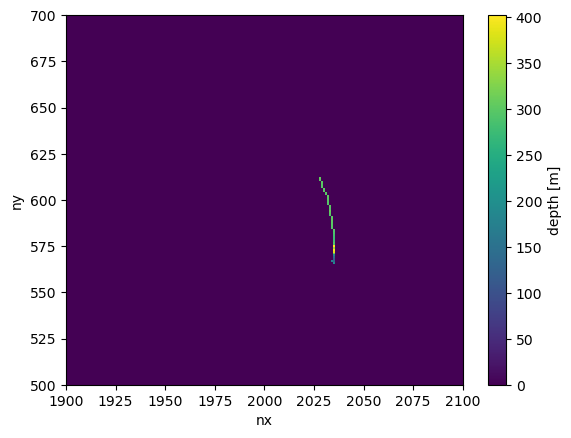

<xarray.DataArray 'depth' (ny: 1442, nx: 4320)> Size: 25MB
array([[   0.    ,    0.    ,    0.    , ...,    0.    ,    0.    ,
           0.    ],
       [   0.    ,    0.    ,    0.    , ...,    0.    ,    0.    ,
           0.    ],
       [   0.    ,    0.    ,    0.    , ...,    0.    ,    0.    ,
           0.    ],
       ...,
       [3469.4622, 3518.4343, 3506.8591, ..., 2563.972 , 2931.4624,
        3247.5532],
       [3558.4404, 3484.4531, 3448.4094, ..., 2559.975 , 2836.1782,
        3213.9343],
       [3376.1716, 3628.9873, 3591.5435, ..., 2515.0188, 2729.5156,
        2744.1062]], shape=(1442, 4320), dtype=float32)
Dimensions without coordinates: ny, nx
Attributes:
    long_name:                   depth
    units:                       m
    grid_type:                   B
    lakes_removed:               
    nonadvective_cells_removed:  yes
    description:                 Charrassin 2025 depth regridded onto global ...

In [40]:
topog_seaice_BearRidge = topog_seaice.copy(deep=True)
topog_seaice_BearRidge = topog_seaice_BearRidge.depth.where(BearRidge_edited_kmt.kmt>0).fillna(0)

(topog_seaice - topog_seaice_BearRidge).depth.plot()
plt.xlim(1900,2100)
plt.ylim(500,700)
plt.show()

topog_seaice_BearRidge.attrs['description'] = 'Charrassin 2025 depth regridded onto global 1/12th (8km) grid, filled elsewhere with GEBCO 2024 data. Generated with notebook https://github.com/claireyung/mom6-panAn-iceshelf-tools/blob/add_charrassin_bathy/generate-draft/Generate-Charrassin-bathy.ipynb.  Then processed to remove grounded ice and enforce a minimum ocean thickness of 5m according to initial conditions in https://github.com/claireyung/mom6-panAn-iceshelf-tools/blob/main/generate-draft/process-topo-8k-minimal-topoedited.ipynb . No water column min/max applied, no topo edits. Isolated seas are removed. Set to zero where ice surface elevation > 0. Masked to find kmt with nonzero values. Manually masked out Bear Ridge in Amundsen sea, see https://github.com/claireyung/mom6-panAn-iceshelf-tools/blob/main/generate-draft/bear-ridge-edits.ipynb'
topog_seaice_BearRidge

In [41]:
topog_seaice_BearRidge.to_netcdf('/g/data/x77/cy8964/mom6/input/input-8km/07.09.26-BearRidgeSI/topog_seaice.nc')

Now create nuopc file (masked one - nomask one will be the same)

```
module use /g/data/vk83/modules
module load payu
module use /g/data/xp65/public/modules
module load conda/analysis3

cd /home/156/cy8964/model-tools/om3-scripts-jun2026/mesh_generation

python3 generate_mesh.py --grid-type=mom --grid-filename=/g/data/vk83/prerelease/configurations/inputs/access-om3/panan.4km/2026.01.08/ocean_hgrid.nc --mesh-filename=/g/data/x77/cy8964/mom6/input/input-8km/07.09.26-BearRidgeSI/access-om3-4km-ESMFmesh.nc --topog-filename=/g/data/x77/cy8964/mom6/input/input-8km/07.09.26-BearRidgeSI/topog_seaice.nc --minimum-depth=0.001 --wrap-lons=True

### Also files for fully masking out ocean here:

Copy the kmt one to `/g/data/x77/cy8964/mom6/input/input-8km/07.09.26-BearRidgeOSI`

```
cp /g/data/x77/cy8964/mom6/input/input-8km/07.09.26-BearRidgeSI/kmt.nc /g/data/x77/cy8964/mom6/input/input-8km/07.09.26-BearRidgeOSI/
cp /g/data/x77/cy8964/mom6/input/input-8km/07.09.26-BearRidgeSI/access-om3-4km-ESMFmesh.nc /g/data/x77/cy8964/mom6/input/input-8km/07.09.26-BearRidgeOSI/

```

Don't need ice shelf when ocean not there

DO need to make topo file:

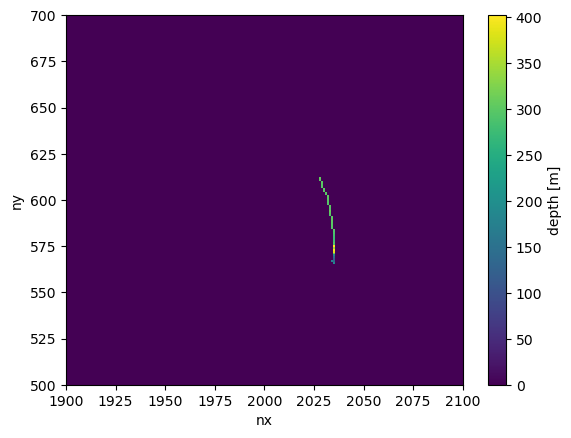

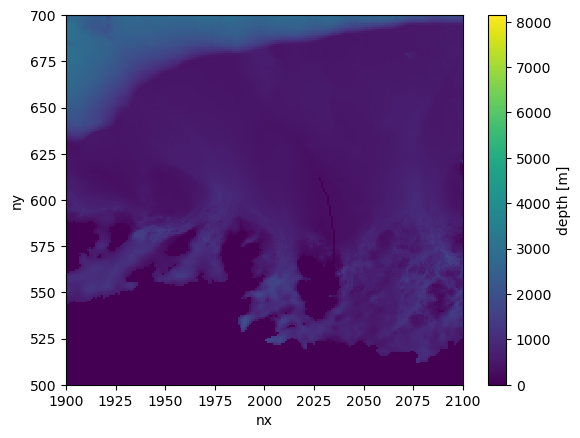

<xarray.Dataset> Size: 100MB
Dimensions:            (ny: 1442, nx: 4320)
Dimensions without coordinates: ny, nx
Data variables:
    depth              (ny, nx) float32 25MB 0.0 0.0 0.0 ... 2.73e+03 2.744e+03
    sea_area_fraction  (ny, nx) float32 25MB ...
    lon                (ny, nx) float32 25MB -280.0 -279.9 ... 79.88 79.96
    lat                (ny, nx) float32 25MB -86.49 -86.49 ... -37.5 -37.5
Attributes:
    original_file:  ./claires_input/topog_IS_with_sea_fraction_Bgrid.nc
    NCO:            netCDF Operators version 5.0.5 (Homepage = http://nco.sf....
    history:        Mon May 18 14:47:53 2026: ncrename -v geolon_t,lon topog_...
    description:    Manually masked out Bear Ridge in Amundsen sea, see https...

In [48]:
topog_BearRidge = topog.copy(deep=True)
topog_BearRidge['depth'] = topog_BearRidge.depth - topog_BearRidge.depth.where(kmt.kmt - BearRidge_edited_kmt.kmt>0).fillna(0)

(topog - topog_BearRidge).depth.plot()
plt.xlim(1900,2100)
plt.ylim(500,700)
plt.show()
(topog_BearRidge).depth.plot()
plt.xlim(1900,2100)
plt.ylim(500,700)
plt.show()

topog_BearRidge.attrs['description'] = 'Manually masked out Bear Ridge in Amundsen sea, see https://github.com/claireyung/mom6-panAn-iceshelf-tools/blob/main/generate-draft/bear-ridge-edits.ipynb'
topog_BearRidge

In [49]:
topog_BearRidge.to_netcdf('/g/data/x77/cy8964/mom6/input/input-8km/07.09.26-BearRidgeOSI/topog.nc')

## SUMMARY 

To turn on new Bear ridge mask I've made two new input file folders

**run 1**: Bear ridge masked out in sea ice only
```
ls /g/data/x77/cy8964/mom6/input/input-8km/07.09.26-BearRidgeSI/
access-om3-4km-ESMFmesh.nc  ice_shelf_thick.nc  kmt.nc  topog_seaice.nc
```
In config.yaml, need to change `access-om3-4km-ESMFmesh.nc`, `ice_shelf_thick.nc`, `kmt.nc` to `/g/data/x77/cy8964/mom6/input/input-8km/07.09.26-BearRidgeSI/` path

*topog_seaice.nc is not used by the model, it is just used for mesh generation.


**run 2**: Bear Ridge masked out in both ocean and sea ice
```
ls /g/data/x77/cy8964/mom6/input/input-8km/07.09.26-BearRidgeOSI/
>> access-om3-4km-ESMFmesh.nc  kmt.nc  topog.nc
```
In config.yaml, need to change `access-om3-4km-ESMFmesh.nc`,  `kmt.nc`,  `topog.nc` to `/g/data/x77/cy8964/mom6/input/input-8km/07.09.26-BearRidgeOSI/` path


**Note** iceberg flux might be a bit wrong now since part of the flux will be going on the now masked out area.